# Mise en oeuvre de K-Means sur les données Iris



In [ ]:
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans



iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=['sepal length','sepal width', 'petal length','petal width'])
y = pd.DataFrame(iris.target, columns=['espece'])

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [6]:
k = 2
model = KMeans(k, n_init=10)
model.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Calcul de l'inertie inter et du score de silhouette pour k de 2 à 9
mesinertieinter = []
sil_score = []
for k in range(2,10):
    model = KMeans(k, n_init=10) # on veut K classes
    model.fit(X)
    mesinertieinter.append([k, model.inertia_])
    sil_score.append(silhouette_score(X,model.predict(X)))
mesinertieinter

[[2, 152.34795176035792],
 [3, 78.85144142614601],
 [4, 57.25600931571816],
 [5, 46.47223015873016],
 [6, 39.03998724608725],
 [7, 34.420191786283894],
 [8, 30.112388528138528],
 [9, 27.861741540115112]]

<Axes: xlabel='k'>

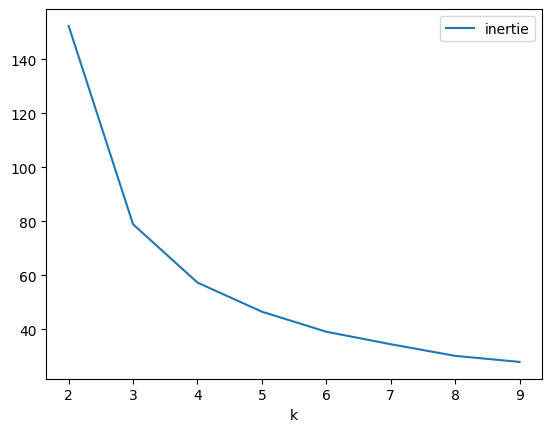

In [9]:
df_mes = pd.DataFrame(mesinertieinter, columns=["k","inertie"])
df_mes.plot.line("k","inertie")

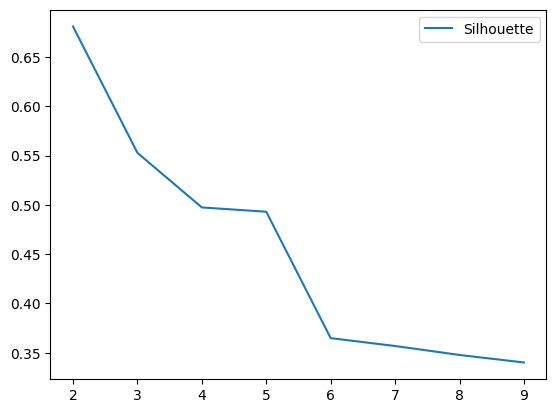

In [10]:
k_range = range(2,10)
plt.plot(k_range,sil_score,label="Silhouette")
plt.legend()

<Axes: xlabel='petal length', ylabel='sepal width'>

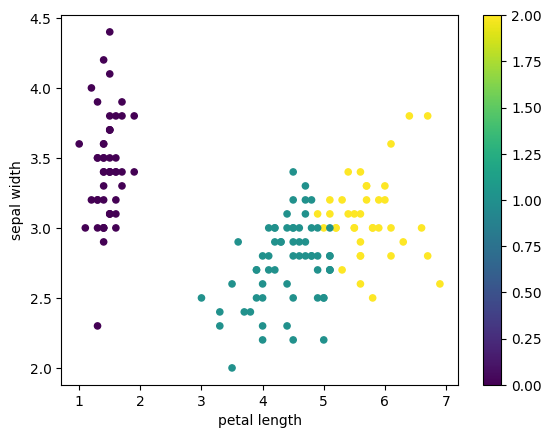

In [13]:
k = 3 # on fixe K=3 classes
model = KMeans(k, n_init=10)
model.fit(X)
df = X[['petal length','sepal width']] 
df.plot.scatter(x='petal length', y='sepal width', c=model.labels_, colormap='viridis')


In [28]:
from sklearn.metrics.cluster import contingency_matrix
clust = KMeans(3)
clust.fit(X)
preds = clust.predict(X)
predsdf = pd.DataFrame(preds, columns=['preds'])

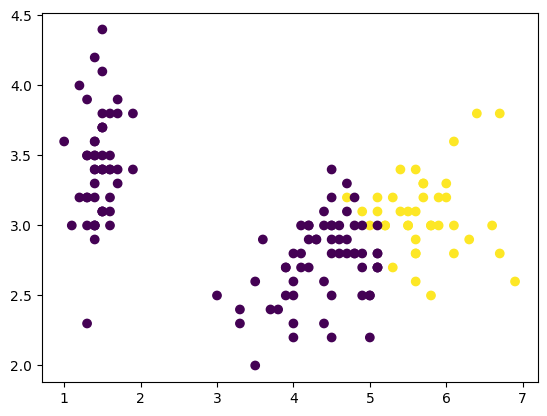

In [29]:
plt.scatter(X["petal length"],X["sepal width"],c=np.where(preds==1,1,-1))

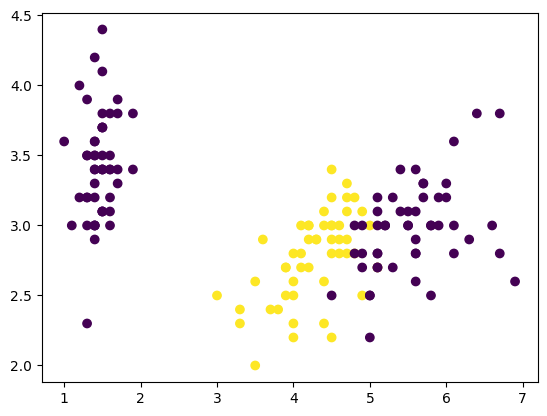

In [30]:
plt.scatter(X["petal length"],X["sepal width"],c=np.where(y==1,1,-1))